# Detector panel results

Four published AI-image detectors scored all 1224 images in `manifest.csv`. This notebook
joins their outputs into one table and looks at what they say.

Nothing here re-runs a detector — it reads `scores/*.csv`, which `./run_all.sh` produced.
Re-running this notebook is cheap, so edit and re-execute freely.

**The panel** (five score columns, because DMimageDetection ships two checkpoints):

| column | method | raw score is |
|---|---|---|
| `cnndetection` | ResNet-50 trained on ProGAN (Wang et al. 2020) | pre-sigmoid logit |
| `univfd` | frozen CLIP ViT-L/14 + linear probe (Ojha et al. 2023) | fc logit |
| `dmimagedetection_progan` | ResNet-50, no-downsample stem, GAN-trained (Corvi et al. 2023) | logit, spatial mean |
| `dmimagedetection_latent` | same architecture, latent-diffusion-trained | logit, spatial mean |
| `aeroblade` | autoencoder reconstruction error, training-free (Ricker et al. 2024) | −LPIPS, max over AEs |

All five are oriented the same way: **higher = more synthetic**. None is thresholded — these
are the raw numbers, which is what a likelihood ratio needs.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

ROOT   = Path.cwd()
SCORES = ROOT / "scores"

DETECTORS = ["cnndetection", "univfd",
             "dmimagedetection_progan", "dmimagedetection_latent",
             "aeroblade"]

REAL, FAKE = "#3b6ea5", "#c4462c"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 9, "axes.titlelocation": "left", "axes.titleweight": "bold",
})

## 1. Join the scores

One row per image, one column per detector.

In [2]:
man = pd.read_csv(ROOT / "manifest.csv")
M = man.copy()

for d in DETECTORS:
    s = pd.read_csv(SCORES / f"{d}.csv")
    assert list(s.columns) == ["image_id", "raw_score"], f"{d}: unexpected columns"
    M = M.merge(s.rename(columns={"raw_score": d}), on="image_id", how="left")

# fail loudly rather than analysing a half-populated table
assert len(M) == len(man), "merge changed the row count"
for d in DETECTORS:
    assert M[d].notna().all(), f"{d}: {M[d].isna().sum()} images unscored"
    assert M[d].std() > 1e-6,  f"{d}: score distribution collapsed"

# provenance: which dataset each authentic image came from
M["source"] = M.image_id.str.split("/").str[0].where(M.label == 0, "fake")
M["release_date"] = pd.to_datetime(M.release_date, errors="coerce")

M.to_csv(SCORES / "master_scores.csv", index=False)
print(f"{len(M)} images x {len(DETECTORS)} detectors -> scores/master_scores.csv")
print(f"labels: {(M.label==0).sum()} authentic / {(M.label==1).sum()} fake")
M.head(3)

1224 images x 5 detectors -> scores/master_scores.csv
labels: 612 authentic / 612 fake


,image_id,path,label,generator_family,release_date,generator,crop_path,cnndetection,univfd,dmimagedetection_progan,dmimagedetection_latent,aeroblade,source
0,COCO2017_train/241483,data/authentic/images/COCO2017_train_241483.jpg,0,authentic,NaT,NaN,data/preprocessed/crop200_align16/COCO2017_tra...,-29.422514,-7.808743,-22.898369,-17.598801,-0.043945,COCO2017_train
1,COCO2017_train/21166,data/authentic/images/COCO2017_train_21166.jpg,0,authentic,NaT,NaN,data/preprocessed/crop200_align16/COCO2017_tra...,-26.814363,-8.683736,-18.760780,-27.846500,-0.028412,COCO2017_train
2,COCO2017_train/429820,data/authentic/images/COCO2017_train_429820.jpg,0,authentic,NaT,NaN,data/preprocessed/crop200_align16/COCO2017_tra...,-24.139183,-4.851563,-6.254888,-15.868666,-0.029297,COCO2017_train


## 2. Where the numbers came from

Each score file has a `.meta.json` sidecar recording the exact weights, upstream commit and
library pins that produced it. If two runs disagree, this is what you compare.

In [3]:
rows = []
for d in DETECTORS:
    m = json.loads((SCORES / f"{d}.meta.json").read_text())
    rows.append({
        "detector": d,
        "score": m["score_semantics"],
        "commit": m["upstream_commit"][:8],
        "crop": m["crop_policy"],
        "torch": m["runtime"]["torch"],
        "device": m["runtime"]["device"],
        "secs": m["elapsed_s"],
    })
prov = pd.DataFrame(rows).set_index("detector")
assert prov.crop.nunique() == 1, "detectors disagree on crop policy"
prov

,score,commit,crop,torch,device,secs
detector,,,,,,
cnndetection,pre_sigmoid_logit,ea0b5622,crop200_align16,2.5.1,cpu,294.5
univfd,fc_logit,030495ae,crop200_align16,2.5.1,cpu,621.4
dmimagedetection_progan,logit_spatial_mean,745ad9e1,crop200_align16,2.5.1,cpu,2916.3
dmimagedetection_latent,logit_spatial_mean,745ad9e1,crop200_align16,2.5.1,cpu,2938.9
aeroblade,neg_lpips_vgg_2_max_over_aes,50fc2b22,crop200_align16,2.5.1,cpu,7623.0


## 3. Do they separate real from fake?

Each detector on its own scale — the logits and AEROBLADE's LPIPS distance are not comparable
as raw numbers, so don't read across panels here. The dashed line is the authentic median.

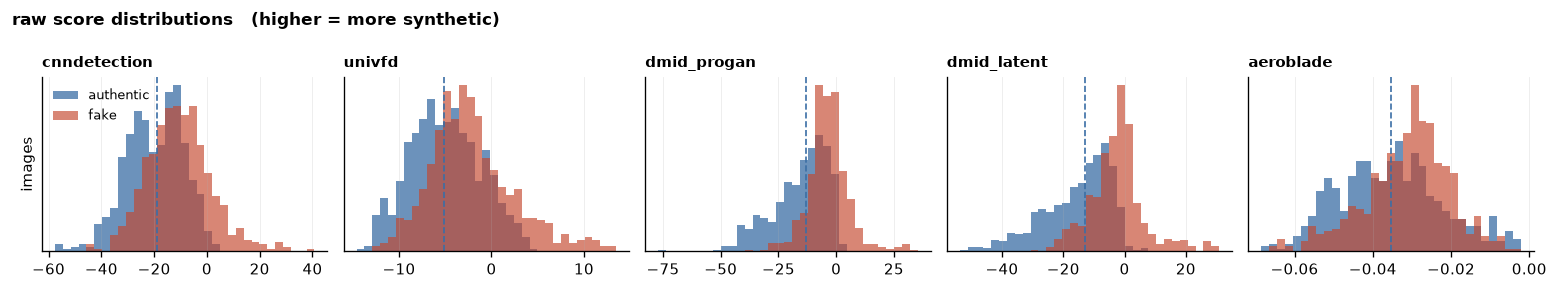

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(13, 2.4))
for ax, d in zip(axes, DETECTORS):
    a, f = M.loc[M.label == 0, d], M.loc[M.label == 1, d]
    bins = np.linspace(M[d].min(), M[d].max(), 34)
    ax.hist(a, bins=bins, color=REAL, alpha=0.75, label="authentic")
    ax.hist(f, bins=bins, color=FAKE, alpha=0.65, label="fake")
    ax.axvline(a.median(), color=REAL, ls="--", lw=1)
    ax.set_title(d.replace("dmimagedetection_", "dmid_"))
    ax.set_yticks([])
axes[0].set_ylabel("images")
axes[0].legend(frameon=False, fontsize=7.5, loc="upper left")
fig.suptitle("raw score distributions   (higher = more synthetic)", x=0.005, ha="left",
             fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. A common scale

To compare detectors we need one. Every score is restated as **how many standard deviations
above the authentic mean** it sits, using that detector's own authentic images as the
reference. `σ = 0` means "looks like a typical real photo"; large positive means "looks
synthetic to this detector".

This is a reading aid, not a calibrated quantity — the real thing is a likelihood ratio,
fitted later.

In [5]:
Z = M.copy()
for d in DETECTORS:
    ref = M.loc[M.label == 0, d]
    Z[d] = (M[d] - ref.mean()) / ref.std()

zcols = {d: d.replace("dmimagedetection_", "dmid_") for d in DETECTORS}
print("median σ-above-authentic, by class")
print(Z.groupby(Z.label.map({0: "authentic", 1: "fake"}))[DETECTORS]
       .median().rename(columns=zcols).round(2).to_string())

median σ-above-authentic, by class
           cnndetection  univfd  dmid_progan  dmid_latent  aeroblade
label                                                               
authentic          0.06   -0.05         0.21         0.24       0.01
fake               0.80    0.59         0.95         1.21       0.43


## 5. Each detector is good at a different thing

AUROC per generator family (authentic images are always the negative class).

**AUROC is the wrong headline statistic for this project** — it is dominated by the bottom of
the fake-score distribution, whereas a likelihood ratio depends on upper-tail discrimination.
It is here as a plumbing check and a rough map of where each detector's competence lies.
Cllr, DET and Tippett come later, on top of `master_scores.csv`.

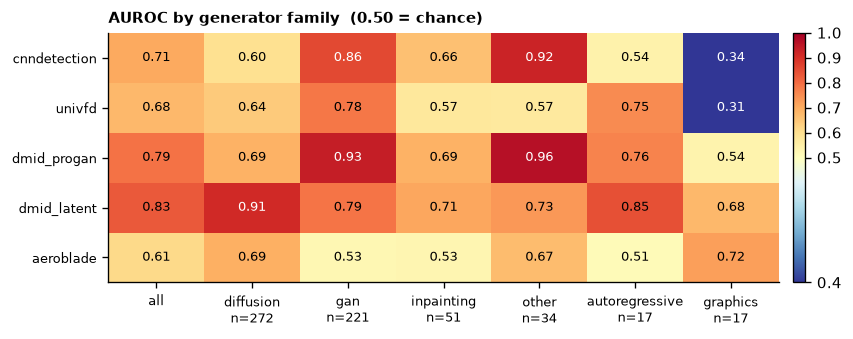

,all,diffusion,gan,inpainting,other,autoregressive,graphics
cnndetection,0.706,0.596,0.858,0.661,0.925,0.539,0.341
univfd,0.677,0.643,0.783,0.571,0.570,0.753,0.310
dmimagedetection_progan,0.792,0.691,0.934,0.690,0.962,0.762,0.536
dmimagedetection_latent,0.832,0.910,0.789,0.709,0.732,0.846,0.679
aeroblade,0.613,0.692,0.525,0.528,0.669,0.514,0.722


In [6]:
def auroc(score, label):
    """Rank-based AUROC; no sklearn in this env."""
    r = pd.Series(score).rank()
    npos, nneg = (label == 1).sum(), (label == 0).sum()
    if npos == 0 or nneg == 0:
        return np.nan
    return (r[label == 1].sum() - npos * (npos + 1) / 2) / (npos * nneg)

fams = [f for f in M.generator_family.unique() if f != "authentic"]
fams = sorted(fams, key=lambda f: -(M.generator_family == f).sum())

tab = pd.DataFrame(index=DETECTORS, columns=["all"] + fams, dtype=float)
for d in DETECTORS:
    tab.loc[d, "all"] = auroc(M[d], M.label)
    for f in fams:
        sub = M[M.generator_family.isin([f, "authentic"])]
        tab.loc[d, f] = auroc(sub[d], sub.label)

counts = {f: int((M.generator_family == f).sum()) for f in fams}
fig, ax = plt.subplots(figsize=(7.2, 2.9))
im = ax.imshow(tab.values.astype(float), cmap="RdYlBu_r",
               norm=TwoSlopeNorm(vmin=0.4, vcenter=0.5, vmax=1.0), aspect="auto")
ax.set_xticks(range(len(tab.columns)))
ax.set_xticklabels([c if c == "all" else f"{c}\nn={counts[c]}" for c in tab.columns], fontsize=8)
ax.set_yticks(range(len(DETECTORS)))
ax.set_yticklabels([zcols[d] for d in DETECTORS], fontsize=8)
ax.grid(False)
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        v = tab.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if (v > 0.85 or v < 0.45) else "black")
ax.set_title("AUROC by generator family  (0.50 = chance)")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout()
plt.show()
tab.round(3)

### What that table says

**The two DMimageDetection checkpoints trade places.** `progan` is the better GAN detector,
`latent` the better diffusion detector — exactly what their training data predicts. They are
not redundant, and running both buys a family-attribution signal neither gives alone.

**AEROBLADE is at chance on GANs (0.53), and that is correct.** It works by checking whether
an image reconstructs suspiciously well through a *latent diffusion* autoencoder. A GAN image
has no reason to. Its weak overall number is the method's scope, not a bug — but it means
AEROBLADE must not be pooled naively into a max aggregator across all families. (At n=4 per
generator this read as *below* chance; with 17 it resolves to chance, which is what the
method's scope actually predicts.)

**CNNDetection drops sharply from GANs to diffusion.** A 2020 detector meeting generators that
postdate it. That decay is the whole reason a time-calibrated framing exists.

## 6. Detector competence decays with generator release date

One point per generator (17 images each), placed at its release date. This is the forward-transfer
question the thesis is built on: does a frozen panel get worse on newer generators?

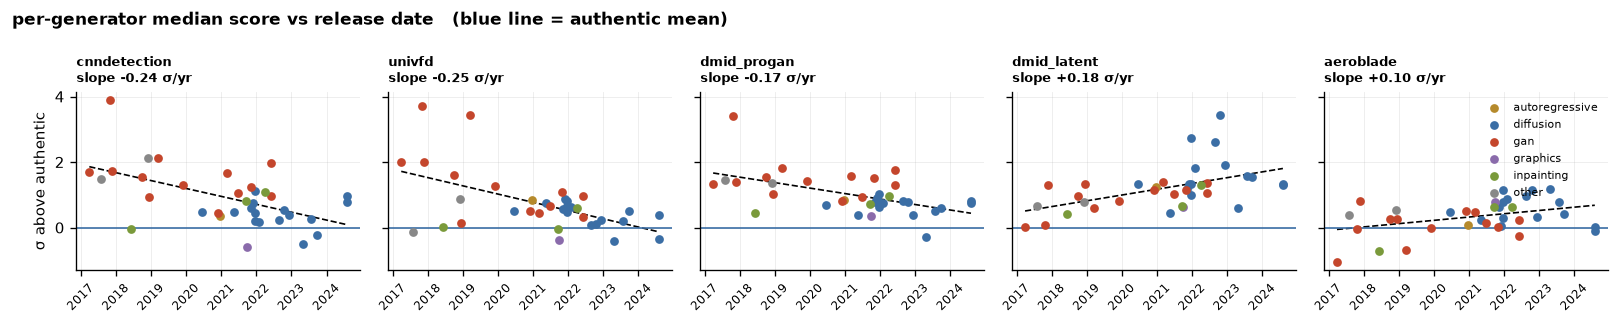

In [7]:
g = (Z[Z.label == 1]
     .groupby(["generator", "generator_family"], as_index=False)
     .agg(date=("release_date", "first"), **{d: (d, "median") for d in DETECTORS})
     .sort_values("date"))

fig, axes = plt.subplots(1, 5, figsize=(13.5, 2.7), sharey=True)
famcolor = {"gan": "#c4462c", "diffusion": "#3b6ea5", "inpainting": "#7a9a3b",
            "autoregressive": "#b58a2c", "graphics": "#8a6bab", "other": "#888888"}
for ax, d in zip(axes, DETECTORS):
    for fam, sub in g.groupby("generator_family"):
        ax.scatter(sub.date, sub[d], s=18, color=famcolor.get(fam, "#888"), label=fam, zorder=3)
    # least-squares trend across all generators
    x = g.date.map(pd.Timestamp.toordinal).to_numpy(float)
    y = g[d].to_numpy(float)
    b, a = np.polyfit(x, y, 1)
    ax.plot(g.date, a + b * x, color="black", lw=1, ls="--", zorder=2)
    ax.axhline(0, color=REAL, lw=1)
    ax.set_title(f"{zcols[d]}\nslope {b*365:+.2f} σ/yr", fontsize=8)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
axes[0].set_ylabel("σ above authentic")
axes[-1].legend(frameon=False, fontsize=6.5, loc="upper right")
fig.suptitle("per-generator median score vs release date   (blue line = authentic mean)",
             x=0.005, ha="left", fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

Read the slope with care: this sample has 17 images per generator and confounds release date
with family (GANs are early, diffusion is late), so a negative slope is not yet evidence of
temporal decay on its own. The family colours are there to let you see that confound.

## 7. Not all real images look equally real

The authentic class is 204 COCO + 204 LAION + 204 RAISE. COCO and LAION are web images; RAISE is
camera-raw. If provenance shifts the scores of *genuine* images, the false-positive rate is
not a single number — which is the thesis's central open question.

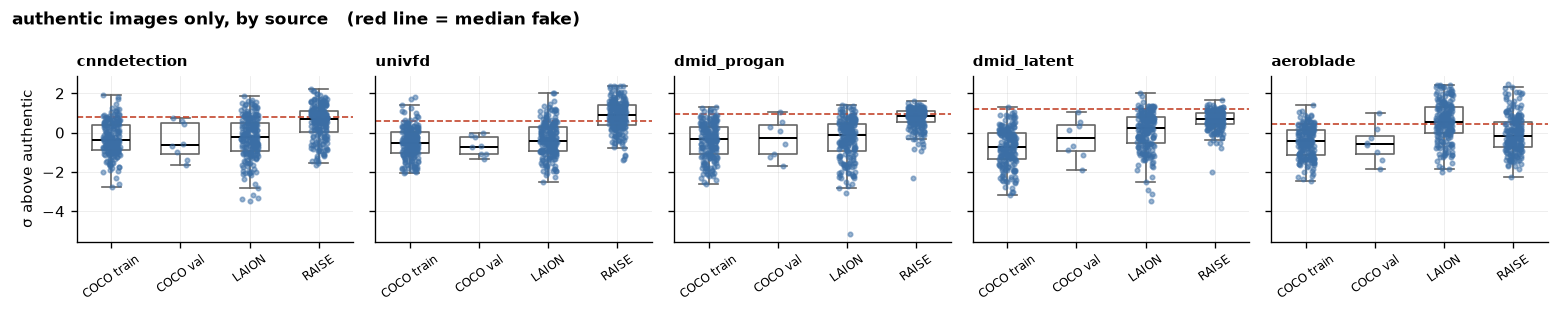

median σ, authentic images by source
                cnndetection  univfd  dmid_progan  dmid_latent  aeroblade
source                                                                   
COCO2017_train         -0.36   -0.50        -0.29        -0.72      -0.43
COCO2017_val           -0.62   -0.70        -0.24        -0.28      -0.57
LAION-400M             -0.21   -0.42        -0.11         0.23       0.56
RAISE                   0.71    0.90         0.87         0.71      -0.18

n per source: {'COCO2017_train': 196, 'COCO2017_val': 8, 'LAION-400M': 204, 'RAISE': 204}


In [8]:
auth = Z[Z.label == 0]
srcs = ["COCO2017_train", "COCO2017_val", "LAION-400M", "RAISE"]
srcs = [s for s in srcs if (auth.source == s).sum() > 0]

fig, axes = plt.subplots(1, 5, figsize=(13, 2.6), sharey=True)
for ax, d in zip(axes, DETECTORS):
    data = [auth.loc[auth.source == s, d].to_numpy() for s in srcs]
    ax.boxplot(data, tick_labels=[s.replace("COCO2017_", "COCO ").replace("-400M", "") for s in srcs],
               widths=0.55, showfliers=False,
               medianprops=dict(color="black", lw=1.2),
               boxprops=dict(color="#666"), whiskerprops=dict(color="#666"),
               capprops=dict(color="#666"))
    for i, s in enumerate(srcs, start=1):
        v = auth.loc[auth.source == s, d]
        ax.scatter(np.full(len(v), i) + np.random.default_rng(0).uniform(-.12, .12, len(v)),
                   v, s=7, alpha=0.5, color=REAL, zorder=3)
    ax.axhline(Z.loc[Z.label == 1, d].median(), color=FAKE, ls="--", lw=1)
    ax.set_title(zcols[d])
    ax.tick_params(axis="x", labelrotation=35, labelsize=7)
axes[0].set_ylabel("σ above authentic")
fig.suptitle("authentic images only, by source   (red line = median fake)",
             x=0.005, ha="left", fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

print("median σ, authentic images by source")
print(auth.groupby("source")[DETECTORS].median().rename(columns=zcols)
          .reindex(srcs).round(2).to_string())
print("\nn per source:", {s: int((auth.source == s).sum()) for s in srcs})

### The RAISE gap

RAISE (camera-raw) sits well above the web-sourced authentic images on all four classifiers —
**+0.94 to +1.36 σ** — it looks *more synthetic* to the panel despite being unambiguously real
photography. That is the direction the "Fake or JPEG?" confound predicts, and it is the
archival-domain-gap problem appearing already.

How far it goes is the part worth sitting with. Comparing the median RAISE *authentic* image
against the median *fake* on the same detector:

| detector | median fake | median RAISE (authentic) |
|---|---|---|
| cnndetection | +0.80 σ | +0.71 σ |
| univfd | +0.59 σ | **+0.90 σ** |
| dmid_progan | +0.95 σ | +0.87 σ |
| dmid_latent | +1.21 σ | +0.71 σ |

On UniversalFakeDetect the typical genuine camera-raw photograph scores *higher* than the
typical synthetic image, and on CNNDetection and dmid_progan the two are within 0.1 σ. Any
single false-positive rate quoted over a mixed authentic class is meaningless at that spread.

AEROBLADE is the exception and runs the other way (−0.25 σ): it is the one panel member not
trained to spot generator artifacts, so it does not inherit whatever cue the classifiers are
keying on here.

Two things still hold it back from being a rate:

- **n = 204** now, not 8 — so this is no longer a small-sample curiosity, and the effect got
  *stronger*, not weaker, with 25× the data.
- **It is still confounded with crop scale.** RAISE images are 4928×3264, so a 200×200 crop
  samples a completely different spatial-frequency regime than a 200×200 crop of a ~500 px web
  image, which is most of the frame. The effect cannot yet be attributed to provenance or
  compression history rather than to the crop policy itself. Varying crop and compression
  separately is what would separate them — and that experiment is now clearly worth running.

## 8. Do the detectors agree?

Max-over-generators aggregation only buys something if the members are not measuring the same
thing. Spearman correlation of the five score columns, fakes only.

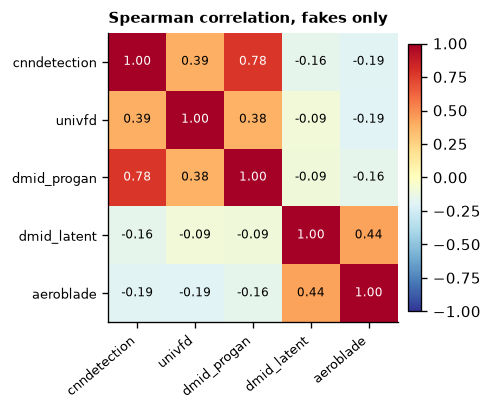

In [9]:
corr = Z.loc[Z.label == 1, DETECTORS].corr(method="spearman")
fig, ax = plt.subplots(figsize=(4.1, 3.5))
im = ax.imshow(corr.values, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels([zcols[d] for d in DETECTORS], rotation=40, ha="right", fontsize=7.5)
ax.set_yticks(range(5)); ax.set_yticklabels([zcols[d] for d in DETECTORS], fontsize=7.5)
ax.grid(False)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i, j]) > 0.7 else "black")
ax.set_title("Spearman correlation, fakes only")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
fig.tight_layout()
plt.show()

## 9. Play with it

`M` holds the raw scores, `Z` the σ-above-authentic version. Two helpers for looking at actual
images — the fastest way to catch a preprocessing problem that no summary statistic will show.

In [10]:
from PIL import Image

def view(image_id, ax=None):
    """Show one image's 200x200 crop with all five scores."""
    row = M.loc[M.image_id == image_id].iloc[0]
    zrow = Z.loc[Z.image_id == image_id].iloc[0]
    if ax is None:
        _, ax = plt.subplots(figsize=(2.6, 2.6))
    ax.imshow(Image.open(ROOT / row.crop_path))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    tag = "FAKE" if row.label else "REAL"
    src = row.generator if row.label else row.source
    ax.set_title(f"{tag} · {src}\n" +
                 "  ".join(f"{zcols[d]} {zrow[d]:+.1f}σ" for d in DETECTORS[:2]),
                 fontsize=6.5)
    return ax

def browse(detector, label=0, n=8, most_synthetic=True):
    """Grid of the n images this detector scored highest (or lowest) within one class.

    label=0, most_synthetic=True  -> the panel's worst false positives
    label=1, most_synthetic=False -> the fakes it missed
    """
    sub = Z[Z.label == label].sort_values(detector, ascending=not most_synthetic).head(n)
    ncol = min(n, 4); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.7 * nrow))
    for ax, (_, r) in zip(np.atleast_1d(axes).ravel(), sub.iterrows()):
        ax.imshow(Image.open(ROOT / r.crop_path))
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        name = r.generator if r.label else r.source
        ax.set_title(f"{name}\n{zcols[detector]} {r[detector]:+.1f}σ", fontsize=7)
    for ax in np.atleast_1d(axes).ravel()[len(sub):]:
        ax.axis("off")
    direction = "most" if most_synthetic else "least"
    fig.suptitle(f"{direction}-synthetic-looking {'authentic' if label==0 else 'fake'} images"
                 f"  ·  by {detector}", x=0.005, ha="left", fontsize=9, fontweight="bold")
    fig.tight_layout()
    return sub[["image_id", "source", "generator", detector]]

The worst false positives — genuine photographs the strongest detector likes least:

,image_id,source,generator,dmimagedetection_progan
559,RAISE/r1a7b8c42t,RAISE,NaN,1.622883
419,RAISE/ree36866dt,RAISE,NaN,1.510614
431,RAISE/r2a151e6dt,RAISE,NaN,1.441556
555,RAISE/ra95f5efet,RAISE,NaN,1.424962
548,RAISE/r185929e9t,RAISE,NaN,1.410367
405,LAION-400M/1073956000515,LAION-400M,NaN,1.403716
355,LAION-400M/1435244002453,LAION-400M,NaN,1.376337
463,RAISE/rea503b5et,RAISE,NaN,1.373616


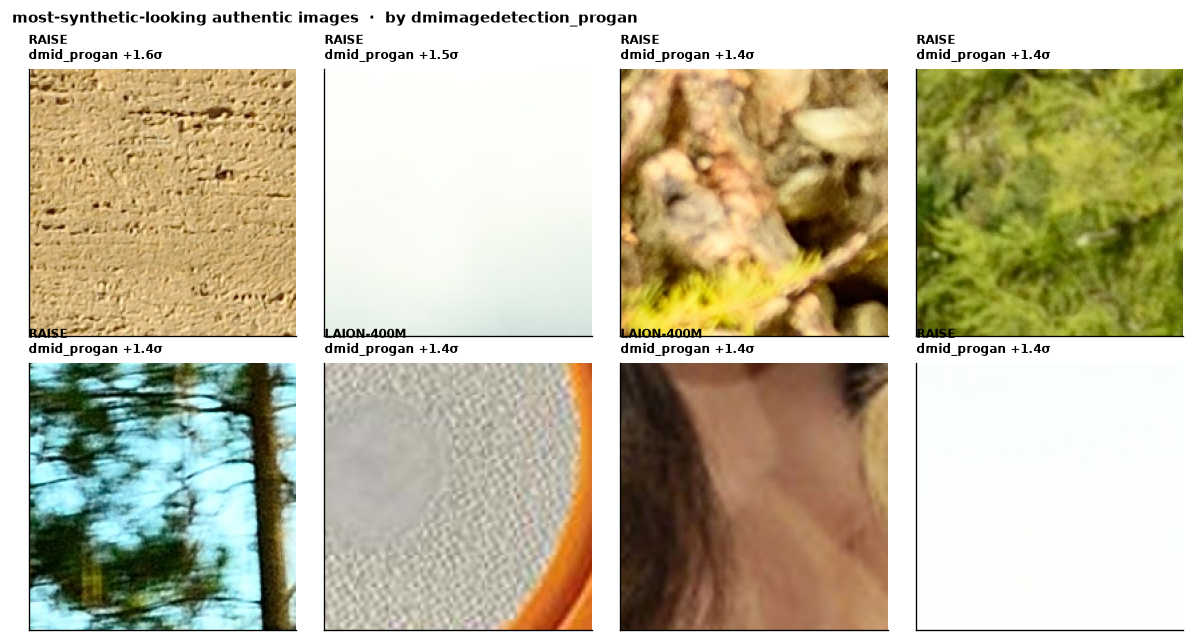

In [11]:
browse("dmimagedetection_progan", label=0, n=8, most_synthetic=True)

And the fakes that slipped through:

,image_id,source,generator,dmimagedetection_progan
1184,Imaginet/dalle3/e0277137-3d6d-4702-8f1b-a90eac...,fake,DALL-E 3,-1.987142
1144,ELSA_D3/train/row1939502/image_gen0,fake,DeepFloyd IF,-1.193535
1149,ELSA_D3/validation/row1369/image_gen0,fake,DeepFloyd IF,-1.147356
914,Artifact/face_synthetics/facesyn/images/img007602,fake,FaceSynthetics,-1.108132
1148,ELSA_D3/train/row56636/image_gen0,fake,DeepFloyd IF,-1.091226
1154,ELSA_D3/validation/row4262/image_gen0,fake,DeepFloyd IF,-1.064236
1140,ELSA_D3/train/row1207115/image_gen0,fake,DeepFloyd IF,-1.008629
1152,ELSA_D3/validation/row2366/image_gen0,fake,DeepFloyd IF,-0.930067


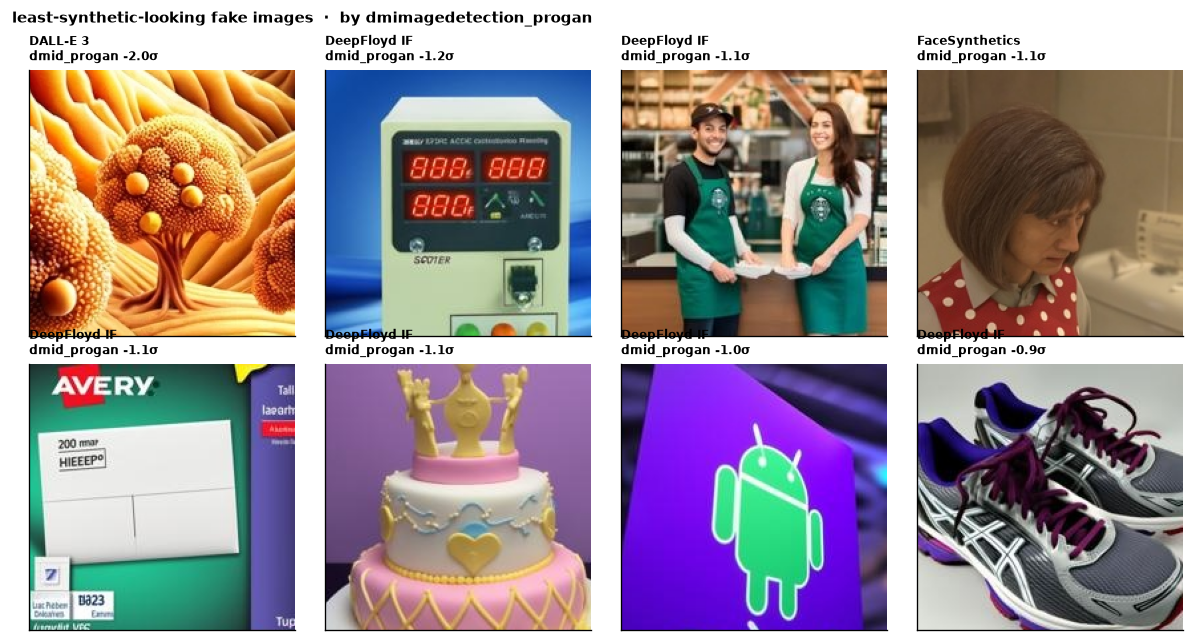

In [12]:
browse("dmimagedetection_progan", label=1, n=8, most_synthetic=False)

## Where this leaves things

**No detector collapsed.** All five produce separated, non-degenerate distributions, so the
plan of a published panel plus per-family score models is viable on this sample; the fallback
to frozen backbone embeddings is not needed.

**The panel is genuinely heterogeneous.** The two DMimageDetection checkpoints specialise in
opposite directions, and AEROBLADE measures something the three classifiers do not. That is
what makes aggregating over them worth doing.

**The authentic class is not homogeneous**, and that is the finding with the most consequence
for the thesis. Any false-positive rate quoted over this sample is an average over three very
different provenances.

### Two caveats that travel with every number above

**All detectors see 200×200 crops**, not their original training resolutions. This was chosen
so that the panel sees byte-identical pixels and so that nothing gets zero-padded — 277 of the
296 images with a short side under 224 px are fakes, so each repo's own default would have made
padding a class cue. It costs fidelity to published benchmark numbers. See the root README's
Caveats.

**AEROBLADE ran with 2 of its 3 autoencoders.** Stability gated the
`stabilityai/stable-diffusion-2*` repos, so SD2's autoencoder needs Hugging Face credentials.
`scores/aeroblade.meta.json` records which ones contributed; `detectors/README.md` says how to
restore the third.

**And the standing asymmetry:** a low score is not evidence of authenticity. It is equally
consistent with degradation, or with a generator no panel member has ever seen.